# Task 2: Season Classification


## 1. Introduction

This notebook predicts catalogue season labels (Spring, Summer, Fall and Winter) from RGB product images. It compares three TensorFlow/Keras model families trained from scratch using the configurations declared in `SELECTED_CONFIGS`:

- **Shallow MLP:** One hidden layer with 128 units on flattened pixels.
- **Deeper MLP:** Hidden layers with 256 and 128 units and dropout.
- **CNN:** Four convolutional blocks with a dense classification head. This main notebook runs the target-specific CNN configuration; broader architecture and scheduling experiments are in `notebooks-test/`.

Model selection ranks supported-class macro-F1, then accuracy, then fewer parameters. Per-class reports, confusion matrices and learning curves describe class errors and convergence. After selection, the internal-test evaluation reports accuracy, supported-class macro-F1, expected calibration error, negative log-likelihood and Brier score. These probability-quality metrics assess uncalibrated predictions; the main workflow does not fit a temperature or review threshold. Submitted models use temperature 1.0 and `review_policy=None`.

All candidates use the same frozen group-isolated partitions and training-only normalization. The internal test had prior development exposure, so its results are descriptive rather than an untouched independent evaluation. The comparison tables and saved outputs describe the completed main run; rerunning training can produce different results across runtimes.

Season predictions describe catalogue labels, not suitability for particular weather.


## 2. Library Imports & Setup

Use the Fashion Keras kernel. The seed controls initialization and augmentation. Float32 is used throughout; GPU availability is reported before models are created.

In [1]:
# Locate the project, import the training libraries, select the accelerator, and fix random seeds.
from pathlib import Path
import sys, json
from concurrent.futures import ThreadPoolExecutor

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageEnhance
from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_recall_fscore_support,
    classification_report,
    log_loss,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import GroupShuffleSplit
from scipy.optimize import minimize_scalar
import tensorflow as tf
from tensorflow import keras
from scripts.preprocessing import (
    task_frame,
    IMAGE_SIZE,
    NORMALISATION_PATH,
    SEED,
    select_tensorflow_device,
)

DEVICE = select_tensorflow_device()
keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()
OUTPUT, RESULTS = (ROOT / 'models', ROOT / 'results')
for directory in (OUTPUT, RESULTS):
    directory.mkdir(parents=True, exist_ok=True)
MAX_EPOCHS, BATCH_SIZE = (30, 64)

def stem_for(target):
    return 'article_type' if target == 'articleType' else target

get_ipython().run_line_magic('matplotlib', 'inline')

# False for a fresh Run All. Enable only when deliberately resuming matching saved.
RESUME_SAVED_RESULTS = False

TensorFlow 2.21.0: /CPU:0


## 3. Load Metadata

Load valid labelled images and their frozen split assignments. Inspect paths, target labels and missing values before preprocessing.

In [2]:
# Load audited metadata and show how many labelled images are available in each frozen split.
metadata_by_target = {'season': task_frame('season')}
frame = metadata_by_target['season']
print('season', frame.shape)
display(frame.head())

season (38591, 15)


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,productDisplayName_repaired,image_path,has_image,group_key,split
0,1163,Men,Apparel,Topwear,Tshirts,Blue,Summer,2011,Sports,Nike Sahara Team India Fanwear Round Neck Jersey,False,/mnt/d/khoile/programs/fashion-intelligence-cl...,True,group_0,train
1,1164,Men,Apparel,Topwear,Tshirts,Blue,Winter,2015,Sports,Nike Men Blue T20 Indian Cricket Jersey,False,/mnt/d/khoile/programs/fashion-intelligence-cl...,True,group_1,train
2,1165,Men,Apparel,Topwear,Tshirts,Blue,Summer,2013,Sports,Nike Mean Team India Cricket Jersey,False,/mnt/d/khoile/programs/fashion-intelligence-cl...,True,group_2,train
3,1525,Unisex,Accessories,Bags,Backpacks,Navy Blue,Fall,2010,Casual,Puma Deck Navy Blue Backpack,False,/mnt/d/khoile/programs/fashion-intelligence-cl...,True,group_3,train
4,1526,Unisex,Accessories,Bags,Backpacks,Black,Fall,2010,Sports,Puma Big Cat Backpack Black,False,/mnt/d/khoile/programs/fashion-intelligence-cl...,True,group_4,train


## 4. Data Preprocessing

Prepare the same images and label encoding for every candidate. Preserve group isolation and fit normalization on training data only.

### 4.1. Class Distribution & Balancing

Preserve the original sample distribution. Initial candidates use unweighted cross-entropy; additional CNN experiments compare this with capped square-root inverse-frequency weights computed only from training counts. No examples are duplicated, and validation metrics remain unweighted.

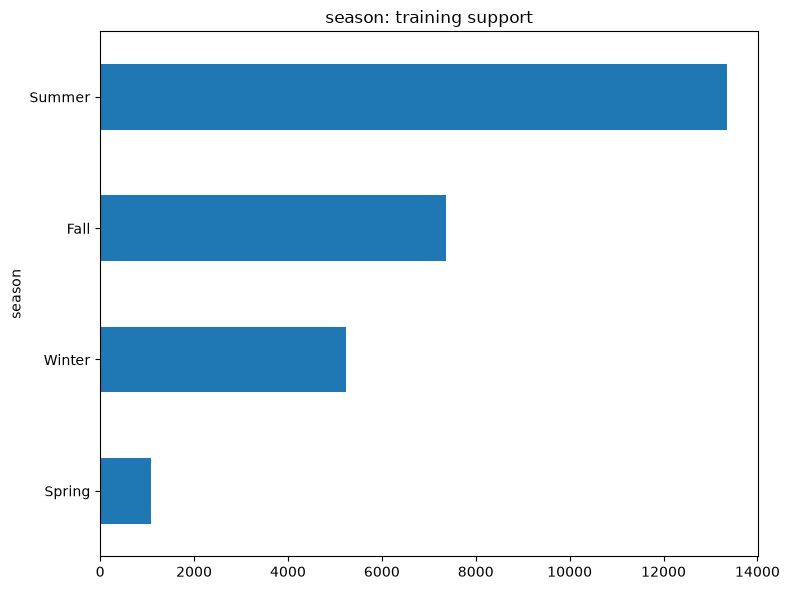

In [3]:
# Measure training-set class imbalance before choosing architectures and evaluation metrics.
train_rows = metadata_by_target['season'].loc[metadata_by_target['season']['split'].eq('train')]
counts = train_rows['season'].value_counts()
counts.head(25).sort_values().plot.barh(figsize=(8, 6), title=f"{'season'}: training support")
plt.tight_layout()
plt.show()

### 4.2. Training, Validation & Test Partitions

Reuse the frozen product-group split. Within validation, use separate groups for selection, temperature fitting and policy checking. Do not use the internal test to select candidates.

In [4]:
# Divide validation groups into model-selection and calibration views without splitting related products.
def validation_views(frame):
    selection_ids, rest_ids = next(
        GroupShuffleSplit(n_splits=1, train_size=0.5, random_state=SEED).split(
            frame, groups=frame.group_key
        )
    )
    selection, rest = frame.iloc[selection_ids], frame.iloc[rest_ids]
    cal_ids, policy_ids = next(
        GroupShuffleSplit(n_splits=1, train_size=0.5, random_state=SEED + 1).split(
            rest, groups=rest.group_key
        )
    )
    return selection, rest.iloc[cal_ids], rest.iloc[policy_ids]

In [5]:
# Create the split views, fixed label order, and reusable batch loaders for each target.
frames, labels_by_target = ({}, {})
selection, calibration, policy = validation_views(
    metadata_by_target['season'].loc[metadata_by_target['season']['split'].eq('validation')]
)
frames['season'] = dict(
    train=metadata_by_target['season'].loc[metadata_by_target['season']['split'].eq('train')],
    selection=selection,
    calibration=calibration,
    policy=policy,
)
groups = [set(frame.group_key) for frame in frames['season'].values()]
assert all((a.isdisjoint(b) for i, a in enumerate(groups) for b in groups[i + 1 :]))
labels_by_target['season'] = sorted(frames['season']['train']['season'].unique())
display(pd.Series({name: len(frame) for name, frame in frames['season'].items()}, name='season'))

train          27038
selection       2964
calibration     1445
policy          1429
Name: season, dtype: int64

### 4.3. Image Preprocessing

Resize RGB to 96 x 128 pixels (width x height), then normalize using training-only channel statistics. The batch class stores decoded uint8 images and converts one batch at a time to float32. Horizontal flips are applied inside each model only during training.

In [6]:
# Cache resized images in RAM and serve normalized batches to Keras during training and evaluation.
class CachedBatches(keras.utils.PyDataset):
    """Decode RGB once to uint8 RAM, then normalize each NHWC batch."""

    def __init__(self, frame, target, labels, normalisation, training=False, batch_size=64):
        super().__init__(workers=0, max_queue_size=2)
        self.dataset = frame
        self.training, self.batch_size = training, batch_size

        def read(path):
            with Image.open(path) as image:
                return np.asarray(
                    image.convert("RGB").resize(IMAGE_SIZE, Image.Resampling.BILINEAR)
                ).copy()

        # Decode and resize each source image once; later epochs reuse this cache.
        with ThreadPoolExecutor(max_workers=4) as pool:
            self.images = np.stack(list(pool.map(read, frame.image_path)))

        # Convert string labels to the fixed integer order expected by the output layer.
        self.targets = np.asarray([labels.index(label) for label in frame[target]], dtype=np.int32)
        self.mean = np.asarray(normalisation["mean"], dtype=np.float32)
        self.std = np.asarray(normalisation["std"], dtype=np.float32)
        self.reset()

    def reset(self):
        self.rng = np.random.default_rng(SEED)
        self.indices = np.arange(len(self.dataset))
        if self.training:
            self.rng.shuffle(self.indices)

    def __len__(self):
        return (len(self.dataset) + self.batch_size - 1) // self.batch_size

    # Normalize only the requested batch to avoid storing a second float32 image copy.
    def __getitem__(self, index):
        ids = self.indices[index * self.batch_size : (index + 1) * self.batch_size]
        images = self.images[ids].astype(np.float32) / 255.0
        return (images - self.mean) / self.std, self.targets[ids]

    def on_epoch_end(self):
        if self.training:
            self.rng.shuffle(self.indices)

### 4.4. Feature Batches & Label Encoding

Map sorted label names to integer indices, preserving the same order for every model. Construct shuffled training batches and fixed-order selection batches.

In [7]:
# Load normalization statistics computed from training images only, then construct all data loaders.
normalisation = json.loads(NORMALISATION_PATH.read_text())
loaders = {}
labels = labels_by_target['season']
loaders['season'] = {
    name: CachedBatches(
        frames['season'][name],
        'season',
        labels,
        normalisation,
        training=name == 'train',
        batch_size=BATCH_SIZE,
    )
    for name in ['train', 'selection']
}

## 5. Model Development & Evaluation

Train and evaluate a shallow MLP baseline, a deeper MLP and a CNN using the same image preprocessing and frozen partitions. Architecture construction, fitting, class-level evaluation, probability-quality assessment and model export are implemented in this notebook. No confidence-calibration or review policy is fitted.

### Evaluation Metric: Macro-F1

Accumulate the full-epoch confusion matrix and average F1 over classes with positive ground-truth support. This metric selects the restored epoch and winning model. It does not average per-batch F1 scores.

The displayed per-class classification report also includes every output label for coverage auditing. Its standard `macro avg` row therefore includes zero-support output labels and can differ from the supported-class macro-F1 used for selection. Read the explicitly reported selection metric for model ranking, and inspect support before making claims about all classes. Selection support is 97/124 article types, 4/4 seasons, 5/5 gender categories and 8/9 occasion labels for this frozen run.

In [8]:
# Track macro-F1 across a complete epoch with a running confusion matrix.
@keras.utils.register_keras_serializable(package="Fashion")
class SupportedMacroF1(keras.metrics.Metric):
    """Macro-F1 over classes present in the full epoch's ground truth."""

    def __init__(self, num_classes, name="macro_f1", **kwargs):
        super().__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.matrix = self.add_weight(
            name="matrix", shape=(num_classes, num_classes), initializer="zeros"
        )

    # Accumulate one confusion matrix across all batches in the epoch.
    def update_state(self, y_true, y_pred, sample_weight=None):
        truth = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        predictions = tf.argmax(y_pred, axis=-1, output_type=tf.int32)
        weights = (
            None if sample_weight is None else tf.cast(tf.reshape(sample_weight, [-1]), self.dtype)
        )
        self.matrix.assign_add(
            tf.math.confusion_matrix(
                truth, predictions, self.num_classes, weights=weights, dtype=self.dtype
            )
        )

    # Average F1 only across classes that are present in the ground truth.
    def result(self):
        support = tf.reduce_sum(self.matrix, axis=1)
        predicted = tf.reduce_sum(self.matrix, axis=0)
        f1 = tf.math.divide_no_nan(2 * tf.linalg.diag_part(self.matrix), support + predicted)
        mask = tf.cast(support > 0, self.dtype)
        return tf.math.divide_no_nan(tf.reduce_sum(f1 * mask), tf.reduce_sum(mask))

    def reset_state(self):
        self.matrix.assign(tf.zeros_like(self.matrix))

    def get_config(self):
        return {**super().get_config(), "num_classes": self.num_classes}

### Saved-Model Metadata

An identity layer stores label order, preprocessing and confidence policy inside each exported Keras model.

In [9]:
# Attach labels and preprocessing settings to the exported Keras model as a pass-through layer.
@keras.utils.register_keras_serializable(package="Fashion")
class ModelMetadata(keras.layers.Layer):
    """Store label order, preprocessing and calibration inside the .keras file."""

    def __init__(self, metadata=None, **kwargs):
        super().__init__(**kwargs)
        self.metadata = dict(metadata or {})

    def call(self, inputs):
        return inputs

    def get_config(self):
        return {**super().get_config(), "metadata": dict(self.metadata)}

In [10]:
# Keep trained models, learning histories, and selection scores organized by target and method.
models = {'season': {}}
histories = {'season': {}}
selection_scores = {}

### General design justification

We fix the input to a 96x128 RGB image, making batching and inference easy and computation tractable. It has a dominant aspect ratio of 60x80 portrait. Resizing doesn’t recover lost details, so we don’t expect bigger inputs to boost recognition. The output units are fixed to the target label vocabulary, not a free-tuned capacity setting.

Flattening is a simple baseline at the pixel level. A shallow MLP tests whether one nonlinear hidden layer is enough, and a deeper MLP tests for more nonlinear transformations. Dense layers do not explicitly preserve local spatial relations and flattening leads to large number of parameters. ReLU Introduces non-linearity. The hidden width and depth are chosen based on validation evidence, not the number of classes.

They are position shared in weight and can learn local appearance patterns, using small 3x3 convolutions. The consecutive blocks allow to combine information from larger image regions. Max pooling reduces spatial dimensions and computational cost, but may lose fine detail . The final 2x2 average-pooled grid restricts the size of the dense head but retains the coarse spatial layout. Batch normalization normalizes the scale of intermediate activations. These design properties motivate the use of CNN, but do not prove that a particular learned filter detects a particular garment feature.

Dropout 0.2 prevents models from depending on a single hidden activation. Horizontal flips in training only expose models to mirrored product views. They are attempts to improve generalization, not guaranties. Adam adapts parameter updates Decreasing its learning rate on a validation plateau results in smaller updates later during CNN training. Early stopping rescores best selection macro-F1 epoch and stops training on no improvement. The fixed seed is for repeatability. Batch size 64 is a practical training setting, not a demonstrated optimum.

Group-isolated partitions prevent leakage of related products, training-only normalization avoids fitting preprocessing to evaluation data, and macro-F1 gives equal weight to each supported class. Further evidence comes from accuracy, class level errors and parameter counts. The measured validation comparison warranted the particular choices. The general principles above explain the intended roles, different labels favor different capacities.

In [11]:
SELECTED_CONFIGS = {
    'season': {
        'shallow_mlp': {
            'method': 'shallow_mlp_128',
            'widths': [128],
            'learning_rate': 0.0001,
            'epochs': 20,
            'patience': 4,
        },
        'deeper_mlp': {
            'method': 'deeper_mlp_two_layers',
            'widths': [256, 128],
            'learning_rate': 0.0003,
            'epochs': 20,
            'patience': 4,
        },
        'cnn': {
            'method': 'cnn_continue',
            'widths': [256],
            'learning_rate': 1e-05,
            'epochs': 30,
            'patience': 7,
        },
    }
}

### 5.1. Shallow MLP (Baseline)

Flattened RGB input is passed through the selected dense layers, with ReLU and dropout 0.2 after each hidden layer.

#### 5.1.1. Season: Model Architecture & Training Configuration

Configuration `shallow_mlp_128`; hidden dense units [128]. Adam 0.0001, maximum 20 epochs, early-stopping patience 4.

In [12]:
# Build the shallow MLP from the selected target-specific configuration.
config = SELECTED_CONFIGS['season']['shallow_mlp']
method = config['method']
keras.utils.set_random_seed(SEED)

# Start with a fixed image input and training-only horizontal augmentation.
layers = [
    keras.Input(shape=(IMAGE_SIZE[1], IMAGE_SIZE[0], 3)),
    keras.layers.RandomFlip('horizontal'),
]
layers.append(keras.layers.Flatten())

# Add the configured hidden classifier layers and dropout regularization.
for width in config['widths']:
    layers.extend([keras.layers.Dense(width, activation='relu'), keras.layers.Dropout(0.2)])
layers.extend([keras.layers.Dense(len(labels_by_target['season'])), ModelMetadata(name='metadata')])
models['season'][method] = keras.Sequential(layers, name=method)
models['season'][method].summary()

I0000 00:00:1789151124.251486   41530 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9709 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "shallow_mlp_128"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 128, 96, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,718,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ metadata (ModelMetadata)        │ (None, 4)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,719,236 (18.00 MB)

 Trainable params: 4,719,236 (18.00 MB)

 Non-trainable params: 0 (0.00 B)

#### 5.1.2. Compile & Train Model

The selection view controls epoch selection. Test images are excluded from training.

In [13]:
# Compile and train the model while restoring the epoch with the best selection macro-F1.
model = models['season'][method]

# Configure optimization and report both accuracy and imbalance-aware macro-F1.
model.compile(
    optimizer=keras.optimizers.Adam(0.0001),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[
        keras.metrics.SparseCategoricalAccuracy(name='accuracy'),
        SupportedMacroF1(len(labels_by_target['season'])),
    ],
)
loaders['season']['train'].reset()

# Stop when selection macro-F1 no longer improves and restore its best weights.
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_macro_f1', mode='max', patience=4, restore_best_weights=True
    )
]

# Keep the selection partition read-only: it chooses epochs but never updates weights.
fitted = model.fit(
    loaders['season']['train'],
    validation_data=loaders['season']['selection'],
    epochs=20,
    callbacks=callbacks,
    shuffle=False,
    verbose=2,
)
histories['season'][method] = pd.DataFrame(fitted.history)

Epoch 1/20


423/423 - 10s - 24ms/step - accuracy: 0.5706 - loss: 1.0082 - macro_f1: 0.5039 - val_accuracy: 0.6387 - val_loss: 0.8286 - val_macro_f1: 0.5759


Epoch 2/20


423/423 - 8s - 19ms/step - accuracy: 0.6116 - loss: 0.9079 - macro_f1: 0.5600 - val_accuracy: 0.6609 - val_loss: 0.8120 - val_macro_f1: 0.6072


Epoch 3/20


...

423/423 - 8s - 20ms/step - accuracy: 0.6893 - loss: 0.7530 - macro_f1: 0.6605 - val_accuracy: 0.6825 - val_loss: 0.7688 - val_macro_f1: 0.6489


Epoch 19/20


423/423 - 8s - 19ms/step - accuracy: 0.6925 - loss: 0.7225 - macro_f1: 0.6656 - val_accuracy: 0.6997 - val_loss: 0.7488 - val_macro_f1: 0.6579


Epoch 20/20


423/423 - 8s - 19ms/step - accuracy: 0.6954 - loss: 0.7272 - macro_f1: 0.6690 - val_accuracy: 0.6744 - val_loss: 0.8070 - val_macro_f1: 0.6356


In [2]:
# Shared plotting helper, reused by each model's evaluation below.
def plot_confusion_figure(counts, target, title):
    """Display row-normalized confusion counts without running inference."""
    # Normalize over every predicted class before selecting rows for display.
    normalized = counts.div(counts.sum(axis=1).replace(0, 1), axis=0)
    fig, ax = plt.subplots(figsize=(9, 7))
    display_matrix = ConfusionMatrixDisplay(normalized.to_numpy(), display_labels=counts.index)
    display_matrix.plot(ax=ax, cmap='Blues', values_format='.2f', xticks_rotation=45)
    display_matrix.im_.set_clim(0, 1)
    # A label with no test examples has undefined recall.
    for row in np.flatnonzero(counts.sum(axis=1).to_numpy() == 0):
        for annotation in display_matrix.text_[row]:
            annotation.set_text('N/A')
    ax.set_title(title)
    ax.set(xlabel='Predicted label', ylabel='True label')
    fig.tight_layout()
    plt.show()
    plt.close(fig)


#### 5.1.3. Evaluation and Performance Metrics

Calculate validation accuracy and supported-class macro-F1, display the per-class classification report, and plot training and validation loss, accuracy and macro-F1. These measurements use the restored best epoch.

selection_accuracy    0.699730
selection_macro_f1    0.657855
dtype: float64

,precision,recall,f1-score,support
Fall,0.711423,0.445980,0.548263,796.00000
Spring,0.857143,0.469565,0.606742,115.00000
Summer,0.671665,0.862550,0.755233,1506.00000
Winter,0.782051,0.669104,0.721182,547.00000
accuracy,0.699730,0.699730,0.699730,0.69973
macro avg,0.755570,0.611800,0.657855,2964.00000
weighted avg,0.709910,0.699730,0.687604,2964.00000


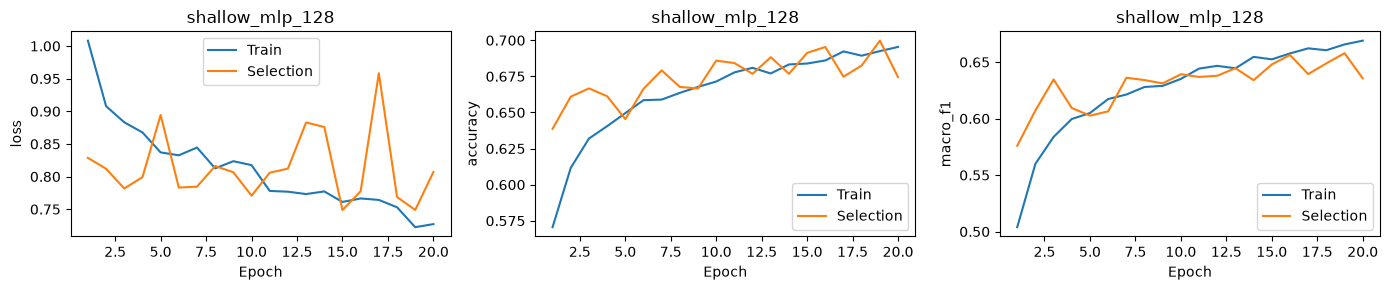

In [ ]:
# Evaluate the restored best weights, show class metrics, and plot the learning curves.
loader = loaders['season']['selection']

# Convert logits to probabilities and preserve the loader's row order.
probabilities = np.vstack(
    [
        tf.nn.softmax(models['season'][method](loader[i][0], training=False)).numpy()
        for i in range(len(loader))
    ]
)
predictions = probabilities.argmax(1)
display(
    pd.Series(
        dict(
            selection_accuracy=accuracy_score(loader.targets, predictions),
            selection_macro_f1=f1_score(
                loader.targets,
                predictions,
                labels=np.unique(loader.targets),
                average='macro',
                zero_division=0,
            ),
        )
    )
)

# Inspect every label because aggregate accuracy can hide minority-class failures.
per_class = pd.DataFrame(
    classification_report(
        loader.targets,
        predictions,
        labels=np.arange(len(labels_by_target['season'])),
        target_names=labels_by_target['season'],
        output_dict=True,
        zero_division=0,
    )
).T
display(per_class)
per_class.to_csv(RESULTS / f"{stem_for('season')}_{method}_selection_per_class.csv")

# Plot train and selection curves to diagnose convergence and overfitting.
history = histories['season'][method]
history.to_csv(RESULTS / f"{stem_for('season')}_{method}_history.csv", index=False)
fig, axes = plt.subplots(1, 3, figsize=(14, 3))
for ax, metric in zip(axes, ['loss', 'accuracy', 'macro_f1']):
    ax.plot(np.arange(1, len(history) + 1), history[metric], label='Train')
    ax.plot(np.arange(1, len(history) + 1), history['val_' + metric], label='Selection')
    ax.set(xlabel='Epoch', ylabel=metric, title=method)
    ax.legend()
fig.tight_layout()
plt.show()

# Store one comparable row for the final cross-family decision.
selection_scores.setdefault('season', {})[method] = dict(
    family='shallow_mlp',
    validation_accuracy=accuracy_score(loader.targets, predictions),
    validation_macro_f1=f1_score(
        loader.targets,
        predictions,
        labels=np.unique(loader.targets),
        average='macro',
        zero_division=0,
    ),
    complexity_parameters=models['season'][method].count_params(),
    epochs_run=len(history),
)

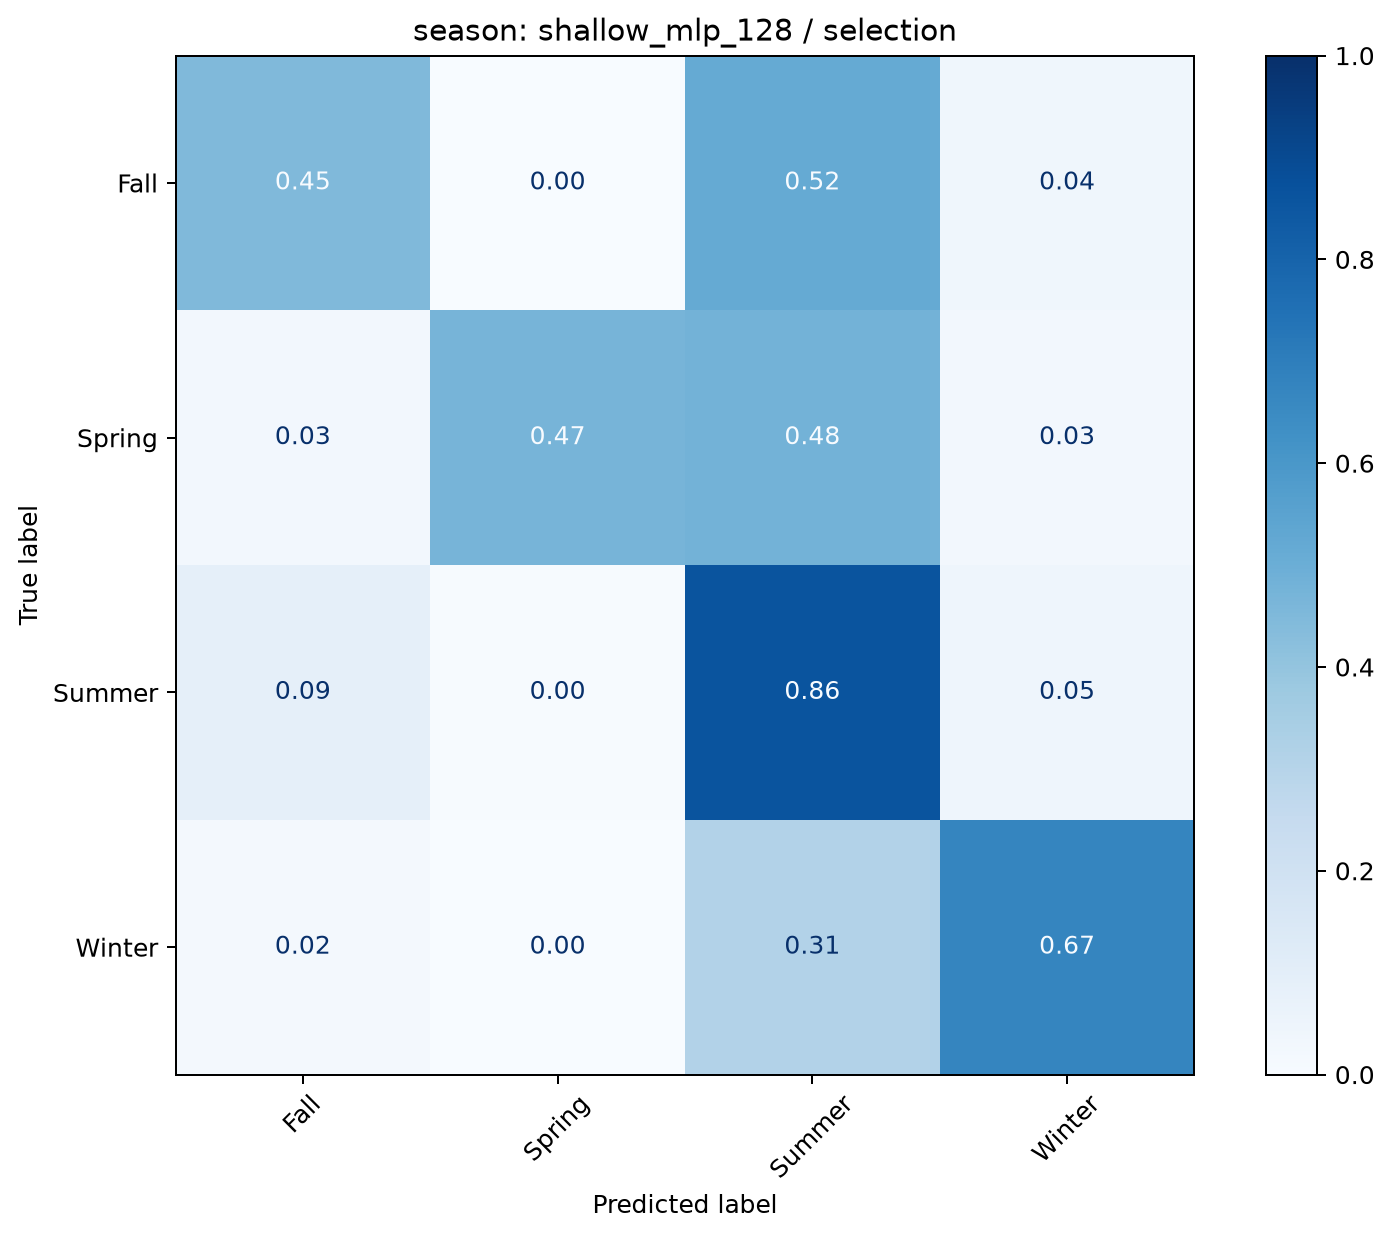

In [ ]:
# Plot this model's selection matrix using the predictions calculated above.
labels = labels_by_target['season']
counts = pd.DataFrame(
    tf.math.confusion_matrix(loader.targets, predictions, num_classes=len(labels)).numpy(),
    index=labels, columns=labels,
)
plot_confusion_figure(
    counts, 'season', f'season: {method} / selection',
)

#### 5.1.4. Evaluation Analysis

The Shallow MLP has 4,719,236 parameters and achieved 69.97% selection accuracy and 0.6579 supported-class macro-F1. The best macro-F1 epoch was 19/20 in the training run. Training accuracy at the epoch was 69.25%. Training loss was 0.7225 and selection loss was 0.7488. It also doesn't provide much evidence that severe overfitting is happening, considering the small accuracy gap. The two evaluation conditions differ in terms of dropout and training only augmentation.

Summer has precision 0.672, recall 0.863 and F1 0.755 (n=1506) Winter has precision 0.782, recall 0.669 and F1 0.721 (n=547) Spring has precision 0.857, recall 0.470 and F1 0.607 (n=115) Fall has precision 0.711, recall 0.446 and F1 0.548 (n=796) 0 of 4 represented classes have zero recall. Supported-class macro-F1 does not include classes not in this partition. 

The dense model compares on flattened pixels, but does not beat the CNN on selection macro-F1. Additional depth does not, in itself, mean better generalization. These results characterize this completed run; broader claims are constrained by minority support and a single random seed.

### 5.2. Deeper MLP

Flattened RGB input is passed through the selected dense layers, with ReLU and dropout 0.2 after each hidden layer.

#### 5.2.1. Season: Model Architecture & Training Configuration

Configuration `deeper_mlp_two_layers`; hidden dense units [256, 128]. Adam 0.0003, maximum 20 epochs, early-stopping patience 4.

In [15]:
# Build the deeper MLP from the selected target-specific configuration.
config = SELECTED_CONFIGS['season']['deeper_mlp']
method = config['method']
keras.utils.set_random_seed(SEED)

# Start with a fixed image input and training-only horizontal augmentation.
layers = [
    keras.Input(shape=(IMAGE_SIZE[1], IMAGE_SIZE[0], 3)),
    keras.layers.RandomFlip('horizontal'),
]
layers.append(keras.layers.Flatten())

# Add the configured hidden classifier layers and dropout regularization.
for width in config['widths']:
    layers.extend([keras.layers.Dense(width, activation='relu'), keras.layers.Dropout(0.2)])
layers.extend([keras.layers.Dense(len(labels_by_target['season'])), ModelMetadata(name='metadata')])
models['season'][method] = keras.Sequential(layers, name=method)
models['season'][method].summary()

Model: "deeper_mlp_two_layers"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (None, 128, 96, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     9,437,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │           516 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ metadata (ModelMetadata)        │ (None, 4)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,470,852 (36.13 MB)

 Trainable params: 9,470,852 (36.13 MB)

 Non-trainable params: 0 (0.00 B)

#### 5.2.2. Compile & Train Model

The selection view controls epoch selection. Test images are excluded from training.

In [16]:
# Compile and train the model while restoring the epoch with the best selection macro-F1.
model = models['season'][method]

# Configure optimization and report both accuracy and imbalance-aware macro-F1.
model.compile(
    optimizer=keras.optimizers.Adam(0.0003),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[
        keras.metrics.SparseCategoricalAccuracy(name='accuracy'),
        SupportedMacroF1(len(labels_by_target['season'])),
    ],
)
loaders['season']['train'].reset()

# Stop when selection macro-F1 no longer improves and restore its best weights.
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_macro_f1', mode='max', patience=4, restore_best_weights=True
    )
]

# Keep the selection partition read-only: it chooses epochs but never updates weights.
fitted = model.fit(
    loaders['season']['train'],
    validation_data=loaders['season']['selection'],
    epochs=20,
    callbacks=callbacks,
    shuffle=False,
    verbose=2,
)
histories['season'][method] = pd.DataFrame(fitted.history)

Epoch 1/20


423/423 - 10s - 24ms/step - accuracy: 0.5053 - loss: 1.3446 - macro_f1: 0.4240 - val_accuracy: 0.5843 - val_loss: 0.9245 - val_macro_f1: 0.5060


Epoch 2/20


423/423 - 9s - 22ms/step - accuracy: 0.5593 - loss: 1.1019 - macro_f1: 0.4917 - val_accuracy: 0.6377 - val_loss: 0.8791 - val_macro_f1: 0.5703


Epoch 3/20


...

423/423 - 9s - 21ms/step - accuracy: 0.6581 - loss: 0.7909 - macro_f1: 0.6168 - val_accuracy: 0.6822 - val_loss: 0.7611 - val_macro_f1: 0.6376


Epoch 19/20


423/423 - 9s - 22ms/step - accuracy: 0.6608 - loss: 0.7879 - macro_f1: 0.6201 - val_accuracy: 0.6869 - val_loss: 0.7581 - val_macro_f1: 0.6458


Epoch 20/20


423/423 - 9s - 22ms/step - accuracy: 0.6614 - loss: 0.7873 - macro_f1: 0.6270 - val_accuracy: 0.6829 - val_loss: 0.7569 - val_macro_f1: 0.6422


#### 5.2.3. Evaluation and Performance Metrics

Calculate validation accuracy and supported-class macro-F1, display the per-class classification report, and plot training and validation loss, accuracy and macro-F1. These measurements use the restored best epoch.

selection_accuracy    0.686910
selection_macro_f1    0.645811
dtype: float64

,precision,recall,f1-score,support
Fall,0.705607,0.379397,0.493464,796.00000
Spring,0.873016,0.478261,0.617978,115.00000
Summer,0.656439,0.866534,0.746995,1506.00000
Winter,0.771134,0.683729,0.724806,547.00000
accuracy,0.686910,0.686910,0.686910,0.68691
macro avg,0.751549,0.601980,0.645811,2964.00000
weighted avg,0.699213,0.686910,0.669807,2964.00000


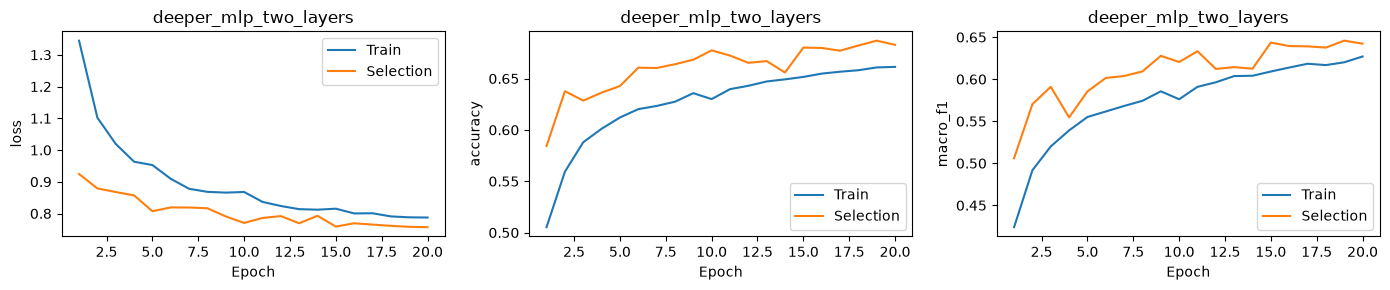

In [ ]:
# Evaluate the restored best weights, show class metrics, and plot the learning curves.
loader = loaders['season']['selection']

# Convert logits to probabilities and preserve the loader's row order.
probabilities = np.vstack(
    [
        tf.nn.softmax(models['season'][method](loader[i][0], training=False)).numpy()
        for i in range(len(loader))
    ]
)
predictions = probabilities.argmax(1)
display(
    pd.Series(
        dict(
            selection_accuracy=accuracy_score(loader.targets, predictions),
            selection_macro_f1=f1_score(
                loader.targets,
                predictions,
                labels=np.unique(loader.targets),
                average='macro',
                zero_division=0,
            ),
        )
    )
)

# Inspect every label because aggregate accuracy can hide minority-class failures.
per_class = pd.DataFrame(
    classification_report(
        loader.targets,
        predictions,
        labels=np.arange(len(labels_by_target['season'])),
        target_names=labels_by_target['season'],
        output_dict=True,
        zero_division=0,
    )
).T
display(per_class)
per_class.to_csv(RESULTS / f"{stem_for('season')}_{method}_selection_per_class.csv")

# Plot train and selection curves to diagnose convergence and overfitting.
history = histories['season'][method]
history.to_csv(RESULTS / f"{stem_for('season')}_{method}_history.csv", index=False)
fig, axes = plt.subplots(1, 3, figsize=(14, 3))
for ax, metric in zip(axes, ['loss', 'accuracy', 'macro_f1']):
    ax.plot(np.arange(1, len(history) + 1), history[metric], label='Train')
    ax.plot(np.arange(1, len(history) + 1), history['val_' + metric], label='Selection')
    ax.set(xlabel='Epoch', ylabel=metric, title=method)
    ax.legend()
fig.tight_layout()
plt.show()

# Store one comparable row for the final cross-family decision.
selection_scores.setdefault('season', {})[method] = dict(
    family='deeper_mlp',
    validation_accuracy=accuracy_score(loader.targets, predictions),
    validation_macro_f1=f1_score(
        loader.targets,
        predictions,
        labels=np.unique(loader.targets),
        average='macro',
        zero_division=0,
    ),
    complexity_parameters=models['season'][method].count_params(),
    epochs_run=len(history),
)

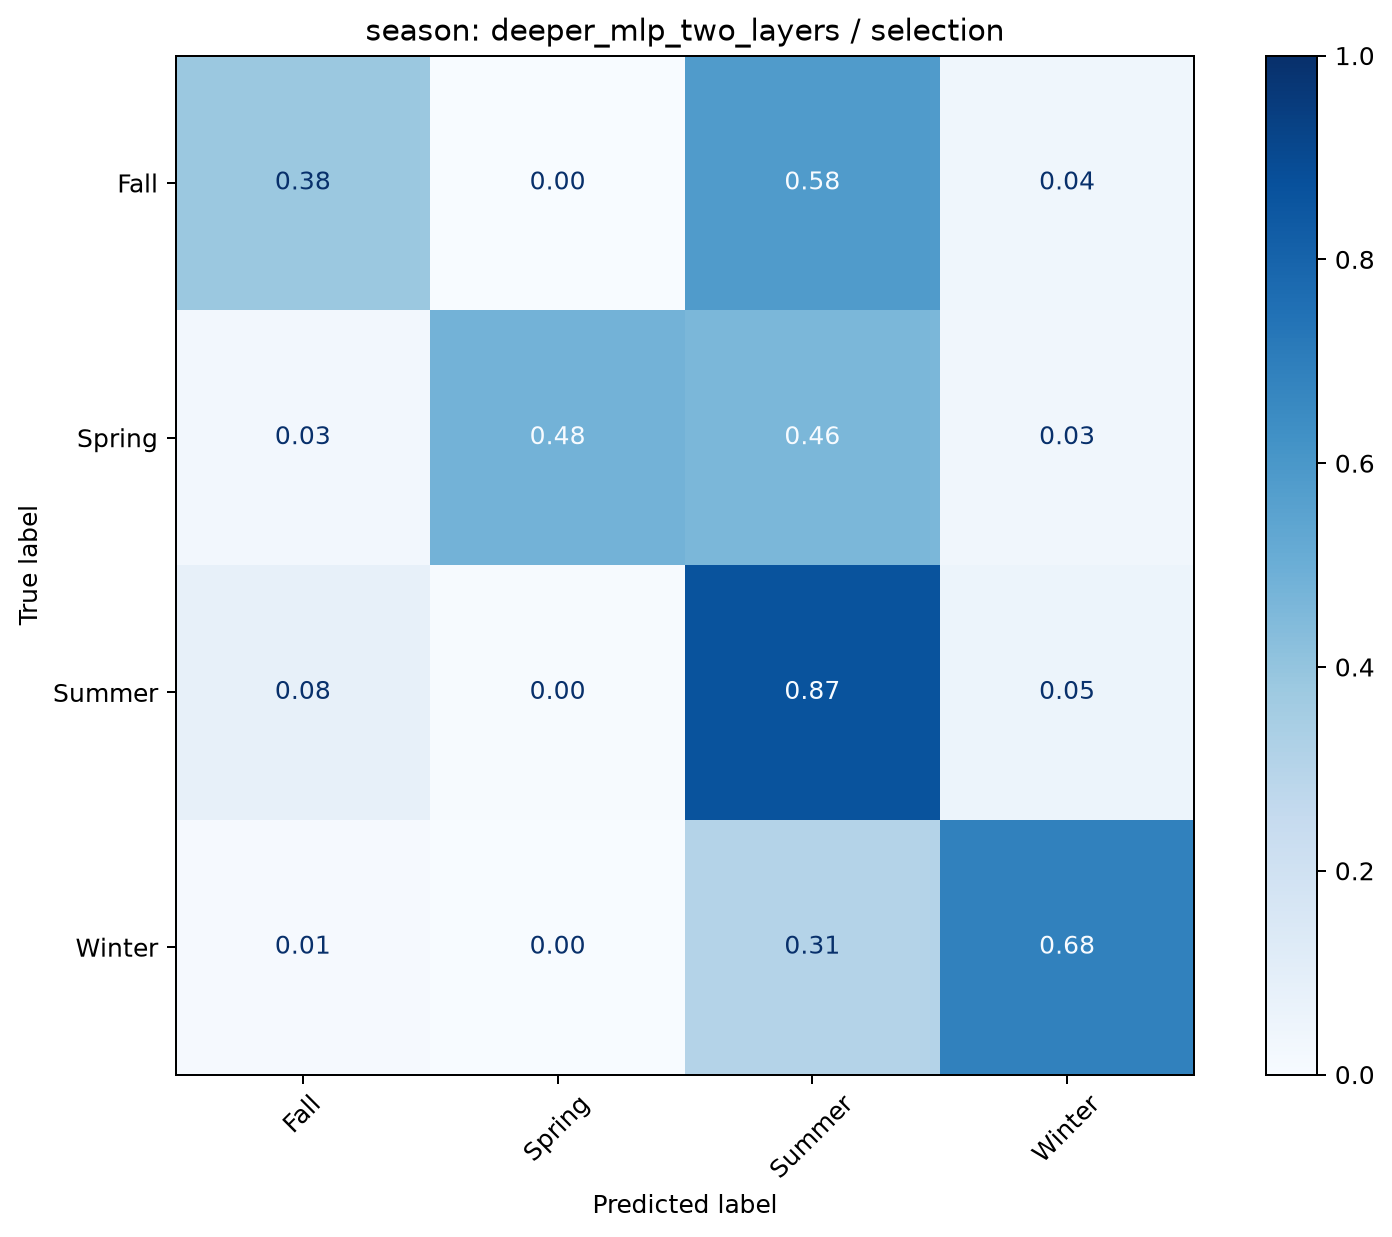

In [ ]:
# Plot this model's selection matrix using the predictions calculated above.
labels = labels_by_target['season']
counts = pd.DataFrame(
    tf.math.confusion_matrix(loader.targets, predictions, num_classes=len(labels)).numpy(),
    index=labels, columns=labels,
)
plot_confusion_figure(
    counts, 'season', f'season: {method} / selection',
)

#### 5.2.4. Evaluation Analysis

The Deeper MLP achieved a selection accuracy of 68.69% and a supported-class macro-F1 of 0.6458, with 9,470,852 parameters. The best macro-F1 epoch was 19/20 in the training run. Training accuracy at that epoch was 66.08% with training loss 0.7879 and selection loss 0.7581. The small accuracy gap indicates that the model does not overfit seriously. Dropout and augmentation for training only create two different evaluation conditions.

Summer: precision 0.656, recall 0.867, F1 0.747 (n=1506); Winter: precision 0.771, recall 0.684, F1 0.725 (n=547); Spring: precision 0.873, recall 0.478, F1 0.618 (n=115); Fall: precision 0.706, recall 0.379, F1 0.493 (n=796). 4 classes, 0 with zero recall. Supported-class macro-F1 does not include classes not in this partition. 

The dense model compares on flattened pixels, but does not beat the CNN on selection macro-F1. Additional depth does not, in itself, mean better generalization. These results characterize this completed run; broader claims are constrained by minority support and a single random seed.

### 5.3. Convolutional Neural Network (CNN)

The selected CNN uses four 3x3 convolution blocks (32, 64, 128, 256 filters), batch normalization, ReLU and max pooling, followed by a 2x2 pooled grid and Dense(256). Only the selected continuation, when required, is fitted.

#### 5.3.1. Season: Model Architecture & Training Configuration

Configuration `cnn_continue`; hidden dense units [256]. Initial Adam 0.001, maximum 30 epochs, early-stopping patience 7 and learning-rate halving after two unimproved epochs. Continuation, if specified, uses eight additional epochs with patience 4 and a fresh optimizer.

In [18]:
# Build the CNN from the selected target-specific configuration.
config = SELECTED_CONFIGS['season']['cnn']
method = config['method']
keras.utils.set_random_seed(SEED)

# Start with a fixed image input and training-only horizontal augmentation.
layers = [
    keras.Input(shape=(IMAGE_SIZE[1], IMAGE_SIZE[0], 3)),
    keras.layers.RandomFlip('horizontal'),
]

# Learn increasingly abstract local features while reducing spatial resolution.
for width in [32, 64, 128, 256]:
    layers.extend(
        [
            keras.layers.Conv2D(width, 3, padding='same'),
            keras.layers.BatchNormalization(),
            keras.layers.Activation('relu'),
            keras.layers.MaxPooling2D(2),
        ]
    )
h, w = IMAGE_SIZE[1] // 16, IMAGE_SIZE[0] // 16
layers.extend([keras.layers.AveragePooling2D((h // 2, w // 2)), keras.layers.Flatten()])

# Add the configured hidden classifier layers and dropout regularization.
for width in config['widths']:
    layers.extend([keras.layers.Dense(width, activation='relu'), keras.layers.Dropout(0.2)])
layers.extend([keras.layers.Dense(len(labels_by_target['season'])), ModelMetadata(name='metadata')])
models['season'][method] = keras.Sequential(layers, name=method)
models['season'][method].summary()

Model: "cnn_continue"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_2 (RandomFlip)      │ (None, 128, 96, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 96, 32)    │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 96, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 96, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 2, 2, 256)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4)              │         1,028 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 653,764 (2.49 MB)

 Trainable params: 652,804 (2.49 MB)

 Non-trainable params: 960 (3.75 KB)

#### 5.3.2. Compile & Train Model

The selection view controls epoch selection. Test images are excluded from training.

In [19]:
# Compile and train the model while restoring the epoch with the best selection macro-F1.
model = models['season'][method]

# Configure optimization and report both accuracy and imbalance-aware macro-F1.
model.compile(
    optimizer=keras.optimizers.Adam(0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[
        keras.metrics.SparseCategoricalAccuracy(name='accuracy'),
        SupportedMacroF1(len(labels_by_target['season'])),
    ],
)
loaders['season']['train'].reset()

# Stop when selection macro-F1 no longer improves and restore its best weights.
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_macro_f1', mode='max', patience=7, restore_best_weights=True
    )
]
callbacks.insert(
    0, keras.callbacks.ReduceLROnPlateau(monitor='val_macro_f1', mode='max', factor=0.5, patience=2)
)

# Keep the selection partition read-only: it chooses epochs but never updates weights.
fitted = model.fit(
    loaders['season']['train'],
    validation_data=loaders['season']['selection'],
    epochs=30,
    callbacks=callbacks,
    shuffle=False,
    verbose=2,
)
histories['season'][method] = pd.DataFrame(fitted.history)
histories['season'][method].to_csv(RESULTS / 'season_cnn_initial_history.csv', index=False)

# Begin the low-learning-rate continuation from the initial CNN weights.
# Reset the loader so continuation starts from a reproducible order.
keras.utils.set_random_seed(SEED)
loaders['season']['train'].reset()
model.compile(
    optimizer=keras.optimizers.Adam(1e-05),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[
        keras.metrics.SparseCategoricalAccuracy(name='accuracy'),
        SupportedMacroF1(len(labels_by_target['season'])),
    ],
)
class_weight = None
fitted = model.fit(
    loaders['season']['train'],
    validation_data=loaders['season']['selection'],
    epochs=8,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_macro_f1', mode='max', patience=4, restore_best_weights=True
        )
    ],
    class_weight=class_weight,
    shuffle=False,
    verbose=2,
)
histories['season'][method] = pd.DataFrame(fitted.history)

Epoch 1/30


2026-09-12 01:31:27.291381: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 92501


423/423 - 29s - 68ms/step - accuracy: 0.5851 - loss: 0.9450 - macro_f1: 0.4972 - val_accuracy: 0.5503 - val_loss: 1.0164 - val_macro_f1: 0.3871 - learning_rate: 0.0010


Epoch 2/30


423/423 - 26s - 61ms/step - accuracy: 0.6571 - loss: 0.8078 - macro_f1: 0.6325 - val_accuracy: 0.5955 - val_loss: 1.1123 - val_macro_f1: 0.4549 - learning_rate: 0.0010


...

423/423 - 26s - 61ms/step - accuracy: 0.7994 - loss: 0.4975 - macro_f1: 0.7891 - val_accuracy: 0.7540 - val_loss: 0.6298 - val_macro_f1: 0.7362


Epoch 7/8


423/423 - 26s - 61ms/step - accuracy: 0.8002 - loss: 0.4956 - macro_f1: 0.7910 - val_accuracy: 0.7567 - val_loss: 0.6299 - val_macro_f1: 0.7393


Epoch 8/8


423/423 - 26s - 62ms/step - accuracy: 0.8014 - loss: 0.4932 - macro_f1: 0.7911 - val_accuracy: 0.7547 - val_loss: 0.6296 - val_macro_f1: 0.7357


#### 5.3.3. Evaluation and Performance Metrics

Calculate validation accuracy and supported-class macro-F1, display the per-class classification report, and plot training and validation loss, accuracy and macro-F1. These measurements use the restored best epoch.

selection_accuracy    0.757760
selection_macro_f1    0.739401
dtype: float64

,precision,recall,f1-score,support
Fall,0.744253,0.650754,0.694370,796.00000
Spring,0.957143,0.582609,0.724324,115.00000
Summer,0.753131,0.838645,0.793591,1506.00000
Winter,0.763916,0.727605,0.745318,547.00000
accuracy,0.757760,0.757760,0.757760,0.75776
macro avg,0.804610,0.699903,0.739401,2964.00000
weighted avg,0.760652,0.757760,0.755348,2964.00000


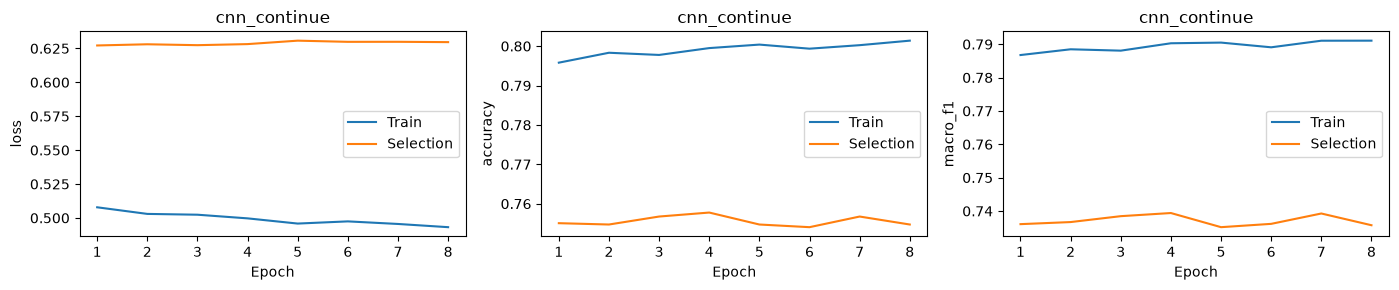

In [ ]:
# Evaluate the restored best weights, show class metrics, and plot the learning curves.
loader = loaders['season']['selection']

# Convert logits to probabilities and preserve the loader's row order.
probabilities = np.vstack(
    [
        tf.nn.softmax(models['season'][method](loader[i][0], training=False)).numpy()
        for i in range(len(loader))
    ]
)
predictions = probabilities.argmax(1)
display(
    pd.Series(
        dict(
            selection_accuracy=accuracy_score(loader.targets, predictions),
            selection_macro_f1=f1_score(
                loader.targets,
                predictions,
                labels=np.unique(loader.targets),
                average='macro',
                zero_division=0,
            ),
        )
    )
)

# Inspect every label because aggregate accuracy can hide minority-class failures.
per_class = pd.DataFrame(
    classification_report(
        loader.targets,
        predictions,
        labels=np.arange(len(labels_by_target['season'])),
        target_names=labels_by_target['season'],
        output_dict=True,
        zero_division=0,
    )
).T
display(per_class)
per_class.to_csv(RESULTS / f"{stem_for('season')}_{method}_selection_per_class.csv")

# Plot train and selection curves to diagnose convergence and overfitting.
history = histories['season'][method]
history.to_csv(RESULTS / f"{stem_for('season')}_{method}_history.csv", index=False)
fig, axes = plt.subplots(1, 3, figsize=(14, 3))
for ax, metric in zip(axes, ['loss', 'accuracy', 'macro_f1']):
    ax.plot(np.arange(1, len(history) + 1), history[metric], label='Train')
    ax.plot(np.arange(1, len(history) + 1), history['val_' + metric], label='Selection')
    ax.set(xlabel='Epoch', ylabel=metric, title=method)
    ax.legend()
fig.tight_layout()
plt.show()

# Store one comparable row for the final cross-family decision.
selection_scores.setdefault('season', {})[method] = dict(
    family='cnn',
    validation_accuracy=accuracy_score(loader.targets, predictions),
    validation_macro_f1=f1_score(
        loader.targets,
        predictions,
        labels=np.unique(loader.targets),
        average='macro',
        zero_division=0,
    ),
    complexity_parameters=models['season'][method].count_params(),
    epochs_run=len(history),
)

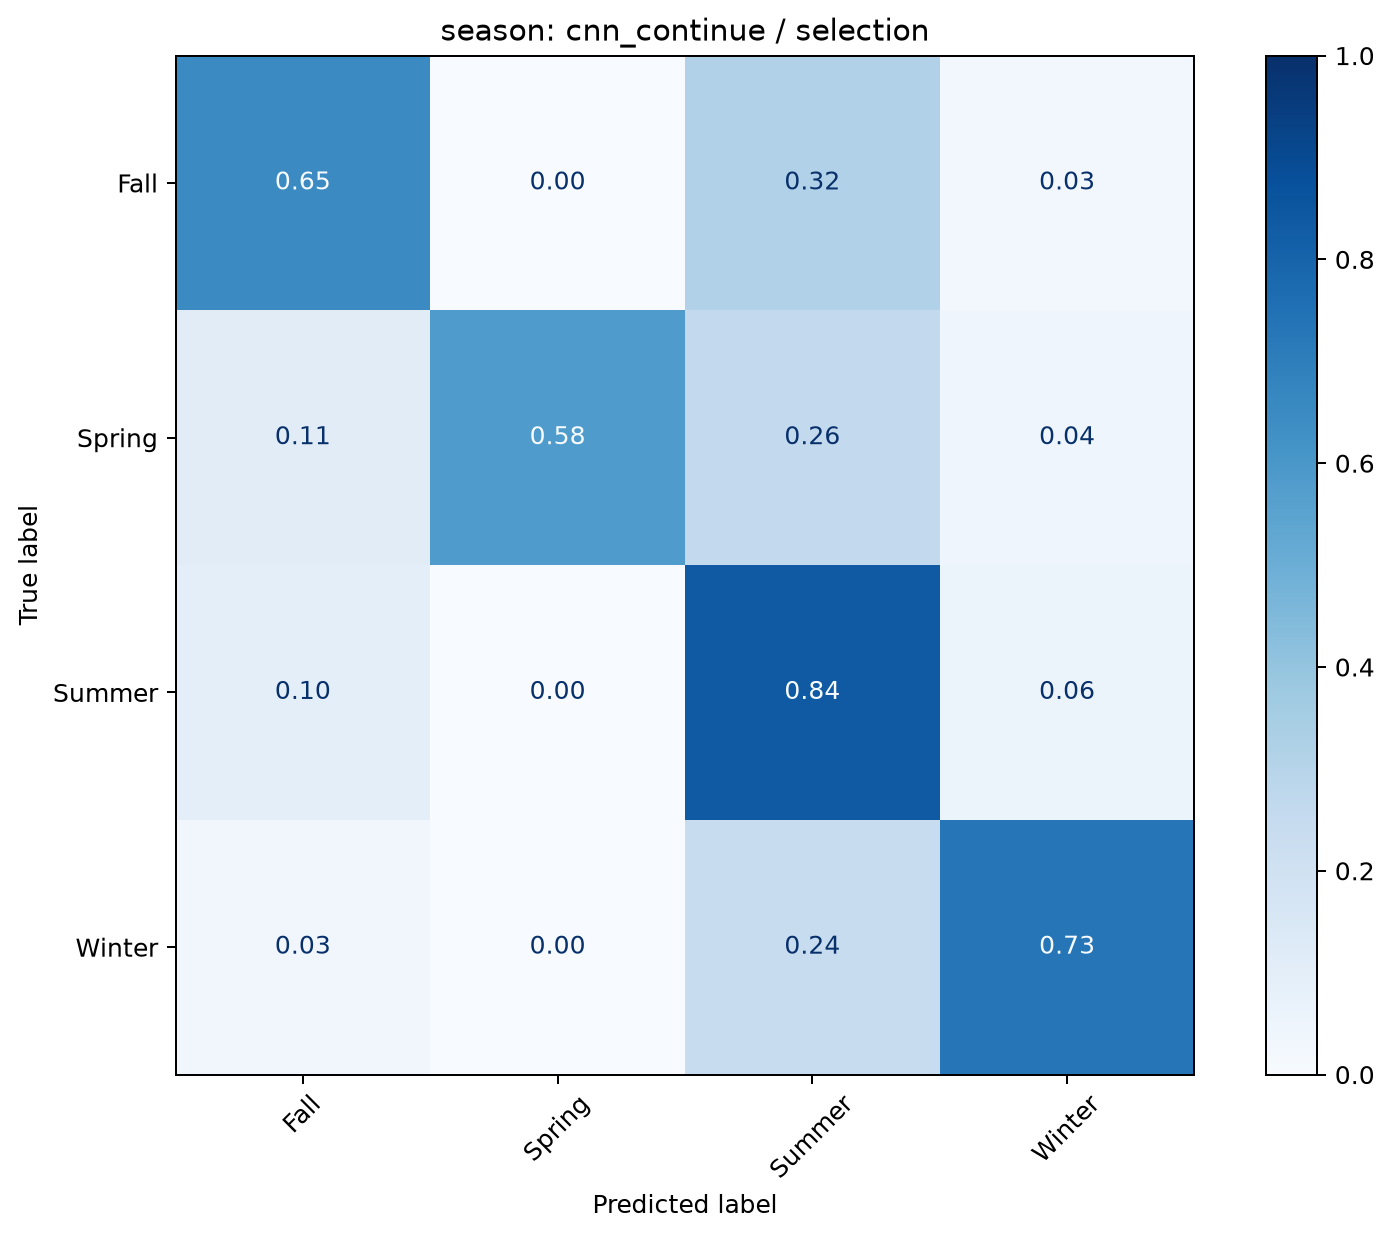

In [ ]:
# Plot this model's selection matrix using the predictions calculated above.
labels = labels_by_target['season']
counts = pd.DataFrame(
    tf.math.confusion_matrix(loader.targets, predictions, num_classes=len(labels)).numpy(),
    index=labels, columns=labels,
)
plot_confusion_figure(
    counts, 'season', f'season: {method} / selection',
)

#### 5.3.4. Evaluation Analysis

The CNN achieved a selection accuracy of 75.78%, a supported-class macro-F1 of 0.7394, and 653,764 parameters. The best macro-F1 epoch was 4 out of 8 in the continuation phase. The training accuracy for that epoch was 79.95% . The training loss was 0.4997 and the selection loss was 0.6282. The accuracy gap indicates some overfitting; the restored checkpoint is based on selection performance, not training accuracy.

The precision, recall and F1 scores for Summer are 0.753, 0.839 and 0.794 (n=1506) respectively, for Winter are 0.764, 0.728 and 0.745 (n=547) respectively, for Spring are 0.957, 0.583 and 0.724 (n=115) respectively and for Fall are 0.744, 0.651 and 0.694 (n=796) respectively. 4 classes, 0 classes with zero recall Supported-class macro-F1 excludes classes absent in this partition. 

This CNN wins the announced selection rule and is exported as the final classifier. Convolution preserves the local image relationships, and provides a more efficient representation than the flattened dense models. These results characterize this completed run, minority support and a single random seed constrain broader claims.

## 6. Ultimate Judgement

The three model families are compared using the validation metrics already calculated in their evaluation sections. The model with the highest validation macro-F1 is selected. Accuracy and parameter count are used to interpret the result and would break an exact macro-F1 tie.

In [21]:
# Prepare containers for the cross-family comparison and final checkpoints.
comparisons, winners, checkpoints = {}, {}, {}

In [22]:
# Rank the three model families by macro-F1, then accuracy, then parameter count.
comparison = pd.DataFrame(selection_scores['season']).T
comparison = comparison.sort_values(
    ['validation_macro_f1', 'validation_accuracy', 'complexity_parameters'],
    ascending=[False, False, True],
)
winners['season'] = comparison.index[0]
comparison['selected'] = comparison.index == winners['season']
comparisons['season'] = comparison
display(comparison)
print('Selected:', winners['season'])
comparison.to_csv(RESULTS / 'season_comparison.csv')

,family,validation_accuracy,validation_macro_f1,complexity_parameters,epochs_run,selected
cnn_continue,cnn,0.75776,0.739401,653764,8,True
shallow_mlp_128,shallow_mlp,0.69973,0.657855,4719236,20,False
deeper_mlp_two_layers,deeper_mlp,0.68691,0.645811,9470852,20,False


Selected: cnn_continue


**Model comparison: season**

| Family | Configuration | Selection accuracy | Macro-F1 | Parameters |
|---|---|---:|---:|---:|
| Shallow MLP | shallow_mlp_128 | 69.97% | 0.6579 | 4,719,236 |
| Deeper MLP | deeper_mlp_two_layers | 68.69% | 0.6458 | 9,470,852 |
| CNN | cnn_continue | 75.78% | 0.7394 | 653,764 |

In [23]:
# Define imbalance-aware performance and probability-calibration metrics for the final test.
def supported_macro_f1(truth, predictions) -> float:
    """Macro-average over labels present in the ground-truth partition."""
    return float(
        f1_score(truth, predictions, labels=np.unique(truth), average="macro", zero_division=0)
    )

def expected_calibration_error(
    truth: np.ndarray,
    probabilities: np.ndarray,
    bins: int = 10,
) -> float:
    """Compute top-label expected calibration error."""
    truth = np.asarray(truth)
    probabilities = np.asarray(probabilities)
    confidence = probabilities.max(axis=1)
    correct = probabilities.argmax(axis=1) == truth
    edges = np.linspace(0.0, 1.0, bins + 1)
    total = len(truth)
    error = 0.0
    for lower, upper in zip(edges[:-1], edges[1:], strict=True):
        selected = (confidence > lower) & (confidence <= upper)
        if selected.any():
            error += (
                selected.sum()
                / total
                * abs(float(correct[selected].mean()) - float(confidence[selected].mean()))
            )
    return float(error)

### 6.1. Selected-Model Evaluation

Evaluate only the selected model on the internal test partition. This cell reports accuracy, supported-class macro-F1, calibration error, negative log-likelihood, Brier score and a per-class classification report. The internal test has prior development exposure and is not used to revise the selected architecture.

In [24]:
# Evaluate each selected family winner once on the untouched internal-test partition.
test_results = {}
checkpoints = {}

method = winners['season']
model = models['season'][method]
test_frame = metadata_by_target['season'].loc[metadata_by_target['season']['split'].eq('test')]
test_loader = CachedBatches(
    test_frame, 'season', labels_by_target['season'], normalisation, batch_size=BATCH_SIZE
)

# Convert logits to probabilities and preserve the loader's row order.
probabilities = np.vstack(
    [
        tf.nn.softmax(model(test_loader[i][0], training=False)).numpy()
        for i in range(len(test_loader))
    ]
)
truth = test_loader.targets
predictions = probabilities.argmax(1)

# Measure label accuracy, class balance, and probability quality on the final test.
metrics = {
    'accuracy': float(accuracy_score(truth, predictions)),
    'macro_f1': supported_macro_f1(truth, predictions),
    'ece': expected_calibration_error(truth, probabilities),
    'nll': float(log_loss(truth, probabilities, labels=np.arange(len(labels_by_target['season'])))),
    'brier': float(
        np.mean(
            np.sum((probabilities - np.eye(len(labels_by_target['season']))[truth]) ** 2, axis=1)
        )
    ),
}
test_results['season'] = dict(
    labels=labels_by_target['season'],
    truth=truth,
    predictions=predictions,
    probabilities=probabilities,
    metrics=metrics,
)

# Bundle the fitted model with everything required to reproduce inference.
checkpoints['season'] = dict(
    target='season',
    labels=labels_by_target['season'],
    model=model,
    model_type=method,
    temperature=1.0,
    review_policy=None,
    mean=normalisation['mean'],
    std=normalisation['std'],
    image_size=list(IMAGE_SIZE),
    comparison_row=comparisons['season'].loc[method].to_dict(),
    test_metrics=metrics,
)
display(pd.Series(metrics, name='season'))

# Inspect every label because aggregate accuracy can hide minority-class failures.
per_class = pd.DataFrame(
    classification_report(
        truth,
        predictions,
        labels=np.arange(len(labels_by_target['season'])),
        target_names=labels_by_target['season'],
        output_dict=True,
        zero_division=0,
    )
).T
display(per_class)
per_class.to_csv(RESULTS / 'season_test_per_class.csv')
pd.Series(metrics).to_csv(RESULTS / 'season_test_metrics.csv')

accuracy    0.739108
macro_f1    0.722528
ece         0.030766
nll         0.642690
brier       0.354454
Name: season, dtype: float64

,precision,recall,f1-score,support
Fall,0.707405,0.634429,0.668933,1551.000000
Spring,0.972789,0.576613,0.724051,248.000000
Summer,0.737314,0.831763,0.781696,2865.000000
Winter,0.755556,0.679353,0.715431,1051.000000
accuracy,0.739108,0.739108,0.739108,0.739108
macro avg,0.793266,0.680539,0.722528,5715.000000
weighted avg,0.742770,0.739108,0.736405,5715.000000


### 6.2. Selected-Model Performance

| Target | Selected model | Selection accuracy | Selection macro-F1 | Internal-test accuracy | Internal-test macro-F1 | ECE | NLL | Brier |
|---|---|---:|---:|---:|---:|---:|---:|---:|
| Season | cnn_continue | 75.78% | 0.7394 | 73.91% | 0.7225 | 0.0308 | 0.6427 | 0.3545 |

All final models use temperature 1.0 and no fitted review policy. Internal-test results have prior development exposure and are descriptive.

In [25]:
# Display the concise final judgement for the chosen model and its internal-test result.
winner = comparisons['season'].loc[winners['season']]
baseline = comparisons['season'].loc[comparisons['season']['family'].eq('shallow_mlp')].iloc[0]
display(
    pd.Series(
        {
            'selected_method': winners['season'],
            'selection_macro_f1': winner.validation_macro_f1,
            'selection_accuracy': winner.validation_accuracy,
            'macro_f1_gain_over_baseline': winner.validation_macro_f1
            - baseline.validation_macro_f1,
            'internal_test_accuracy': test_results['season']['metrics']['accuracy'],
            'internal_test_macro_f1': test_results['season']['metrics']['macro_f1'],
        },
        name='season',
    )
)

selected_method                cnn_continue
selection_macro_f1                 0.739401
selection_accuracy                  0.75776
macro_f1_gain_over_baseline        0.081546
internal_test_accuracy             0.739108
internal_test_macro_f1             0.722528
Name: season, dtype: object

## 7. Final Prediction

Save the selected Keras model with its label order and preprocessing metadata, reload it, and run one sample prediction. This functional check uses softmax probabilities with temperature 1.0; it does not add a separate confidence-calibration or review policy.

In [26]:
# Export a self-contained inference model with preprocessing and label metadata embedded.
def save_checkpoint(checkpoint, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path = path.with_suffix(".keras")
    model = checkpoint["model"]

    # Separate serializable metadata from the live Keras model object.
    metadata = {key: value for key, value in checkpoint.items() if key != "model"}
    metadata = json.loads(json.dumps(metadata, default=lambda value: value.item()))
    model.get_layer("metadata").metadata = metadata

    # Export architecture, learned weights and metadata without optimizer slots.
    # Rebuild without optimizer state to keep the deployment file smaller.
    inference_model = type(model).from_config(model.get_config())
    inference_model.set_weights(model.get_weights())
    inference_model.save(path)
    return path

In [27]:
# Save the selected model, its learning history, and a machine-readable experiment summary.
stem, method = (stem_for('season'), winners['season'])
path = save_checkpoint(  # Bundle the fitted model with everything required to reproduce inference.
    checkpoints['season'], OUTPUT / f'{stem}_model.keras'
)
histories['season'][method].to_csv(RESULTS / f'{stem}_history.csv', index=False)
summary = dict(
    target='season',
    selected=method,
    cnn_selected=SELECTED_CONFIGS['season']['cnn']['method'],
    framework='tensorflow_keras',
    model_file=path.name,
    test_metrics=test_results['season']['metrics'],
    split_sizes={name: len(frame) for name, frame in frames['season'].items()},
    test_scope='internal_test_with_prior_development_exposure',
)
(RESULTS / f'{stem}_summary.json').write_text(json.dumps(summary, indent=2) + '\n')
print('Saved', path)

Saved /mnt/d/khoile/programs/fashion-intelligence-classification/models/season_model.keras


### 7.1. Load the Saved Model & Predict

A successful reload checks the saved architecture and metadata. This example is a functional check, not an independent quality estimate.

In [28]:
# Reload an exported Keras classifier and recover the metadata stored inside it.
def resolve_classifier_path(path):
    path = Path(path)
    if path.exists():
        return path
    raise FileNotFoundError(
        f"Missing trained classifier: {path}. Run the classification notebook first."
    )

def load_checkpoint(path):
    path = resolve_classifier_path(path)
    if path.suffix == ".keras":
        model = keras.models.load_model(path, compile=False)
        return {**dict(model.get_layer("metadata").metadata), "model": model}
    raise ValueError(f"Unsupported classifier format: {path.suffix}")

In [29]:
# Run a single-image smoke test through the same preprocessing path used by the application.
checkpoint = load_checkpoint(OUTPUT / f"{stem_for('season')}_model.keras")

# Apply the embedded preprocessing values rather than notebook globals.
with Image.open(frames['season']['selection'].image_path.iloc[0]) as image:
    resized = image.convert('RGB').resize(
        tuple(checkpoint['image_size']), Image.Resampling.BILINEAR
    )
    inputs = (
        np.asarray(resized, dtype=np.float32) / 255.0 - np.asarray(checkpoint['mean'])
    ) / np.asarray(checkpoint['std'])
probabilities = tf.nn.softmax(
    checkpoint['model'](inputs[None, ...], training=False), axis=-1
).numpy()[0]
indices = np.argsort(probabilities)[::-1][:3]
print(
    {
        'target': 'season',
        'label': checkpoint['labels'][int(indices[0])],
        'confidence': float(probabilities[indices[0]]),
        'top_k': [
            {'label': checkpoint['labels'][int(i)], 'confidence': float(probabilities[i])}
            for i in indices
        ],
    }
)

{'target': 'season', 'label': 'Summer', 'confidence': 0.6556400060653687, 'top_k': [{'label': 'Summer', 'confidence': 0.6556400060653687}, {'label': 'Fall', 'confidence': 0.30601704120635986}, {'label': 'Spring', 'confidence': 0.022457104176282883}]}


## 8. Conclusion

The final CNN achieves 75.78% selection accuracy and 0.7394 macro-F1, exceeding the shallow MLP by 0.0815 macro-F1 and 5.80 accuracy percentage points. It uses 653,764 parameters, compared with 4,719,236 for the baseline. Internal-test accuracy is 73.91% and macro-F1 is 0.7225. Improved Fall and Spring coverage supports the decision, but a catalogue season does not verify weather suitability.

The per-class evidence explains why aggregate scores must be interpreted cautiously. CNNs improve the spatial representation with fewer parameters, but do not eliminate errors on ambiguous or sparsely represented labels. A small training gap alone does not establish useful recognition: the dense models can have similar training and selection accuracy while missing minority classes. Additional layers are therefore judged by observed selection performance rather than presumed capacity.

The final Keras files embed label ordering, image size and normalisation metadata and use unscaled softmax probabilities. ECE, negative log-likelihood and Brier score quantify probability quality; none guarantees correct predictions. The selected models support application inference, and article-type embeddings are evaluated separately in Task 4.

These internal-test results have prior development exposure and come from one training seed. They describe performance on this catalogue rather than independent external generalisation. Further work should collect minority examples, review ambiguous annotations, repeat group-aware evaluation across seeds and test on a separate catalogue. This would assess ranking stability without using the exposed internal test to choose further configurations.